In [36]:
import importlib, GallenModel, Landslidev2, metrics
from typing import Optional
importlib.reload(GallenModel)
importlib.reload(Landslidev2)
importlib.reload(metrics)
from tensorflow.keras.callbacks import CSVLogger
from sklearn.metrics import confusion_matrix
from tensorflow.keras import metrics
import tensorflow as tf
import json
import numpy as np
from tensorflow.keras.models import load_model
from imblearn.over_sampling import SMOTE
from imblearn import pipeline, under_sampling
import keras_tuner as kt
import sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
import os
from matplotlib import pyplot as plt
import geopandas as gpd
import seaborn as sns
import shap
import pandas as pd
from Landslidev2 import CotabatoModel, calculate_newmark
from metrics import plot_landslide_distribution, plot_susceptibility_map
import time

In [37]:
pd.set_option('display.max_colwidth', None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [38]:
print(tf.keras.__version__)

3.10.0


In [39]:
pd.set_option('display.max_colwidth', None)
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Training.gpkg')
print(df.columns)
df = df[df['Slope_mean'] > 10.5]
print(f"Original Dataframe shape: {df.shape}")

print(f" Dataframe shape after modifications and cleaning: {df.shape}")

print(f" Rows that has slope <= 10.5: {df[df['Slope_mean'] < 10.5].shape}")
df = df[df['Slope_mean'] >= 10.5]

# df['landslide'] = df['Landslide']

df.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'], inplace=True)
print(f" Dataframe shape after removing slopes < 10.5: {df.shape}")

original_df_cols = df.columns
df.dropna(subset=list(original_df_cols), inplace=True) #cleans the dataframe by removing null rows for all columns

#encode string column to integer
df['Soil_Type'], _ = pd.factorize(df['Soil Type'])

original_df_cols = df.columns

df.columns, df[['PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean']].head(), df['Soil_Type'].value_counts()

Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
       'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
       'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
       'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean', 'landslide', 'landslide_probability',
       'landslide_preds', 'confusion', 'sus_pinn_landslide',
       'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction',
       'geometry'],
      dtype='object')
Original Dataframe shape: (57891, 33)
 Dataframe shape after modifications and cleaning: (57891, 33)
 Rows that has slope <= 10.5: (0, 33)
 Dataframe shape after removing slopes < 10.5: (57891, 25)


(Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
        'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
        'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
        'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
        'Soil Type', 'BUK_mean', 'landslide', 'geometry', 'Soil_Type'],
       dtype='object'),
    PGA1_max   Prc_mean   Distrv_min   distrd_min  Soil Type   BUK_mean
 0  0.225314  234.86586  2058.008545  2042.008789          0  10.484130
 1  0.225314  234.86586  2184.032959  2178.003662          0  10.480768
 2  0.218405  234.86586  2250.000000  2256.014160          0  10.476539
 3  0.202994  234.86586  1198.874512  1187.139404          0  10.921050
 4  0.202994  234.86586  1284.056030  1266.570190          0  10.907936,
 Soil_Type
 0    33009
 1    24659
 2      222
 3        1
 Name: count, dtype: int64)

In [40]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'Soil Type']
columns = [col for col in list(original_df_cols) if col not in cols_remove]
columns, df[columns].head()

(['Clay_mean',
  'Sand_mean',
  'Silt_mean',
  'NDVI_mean',
  'Est_mean',
  'Nrt_mean',
  'HorCurv_mean',
  'VertCurv_mean',
  'Slope_mean',
  'Elev_mean',
  'SoilThc_mean',
  'DistFlt_min',
  'LULC_majority',
  'TWI_mean',
  'PGA1_max',
  'Prc_mean',
  'Distrv_min',
  'distrd_min',
  'BUK_mean',
  'landslide',
  'Soil_Type'],
     Clay_mean   Sand_mean   Silt_mean  NDVI_mean  Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  Slope_mean    Elev_mean  ...  DistFlt_min  LULC_majority  TWI_mean  PGA1_max   Prc_mean   Distrv_min   distrd_min   BUK_mean  landslide  Soil_Type
 0  360.346280  340.681485  298.954953   0.665530 -0.836117  0.452621      0.000846       0.000460   26.916097  1920.972112  ...  5593.218750            4.0  3.568248  0.225314  234.86586  2058.008545  2042.008789  10.484130          1          0
 1  360.539905  341.044167  298.269993   0.515360 -0.642881  0.510736      0.000765       0.000549   30.162405  1948.885717  ...  5535.918945            4.0  3.044424  0.225314 

In [41]:
cols_remove_for_sampling = ['landslide']
sampling_columns = [col for col in columns if col not in cols_remove_for_sampling]
print(sampling_columns)

['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'Soil_Type']


In [42]:
df[sampling_columns].corr()

,Clay_mean,Sand_mean,Silt_mean,NDVI_mean,Est_mean,Nrt_mean,HorCurv_mean,VertCurv_mean,Slope_mean,Elev_mean,SoilThc_mean,DistFlt_min,LULC_majority,TWI_mean,PGA1_max,Prc_mean,Distrv_min,distrd_min,BUK_mean,Soil_Type
Clay_mean,1.000000,-0.343836,-0.679170,0.176717,0.023641,-0.061613,0.012705,0.002747,-0.079070,-0.151469,-0.075698,0.239285,0.191900,0.021874,-0.096858,-0.075589,-0.076086,-0.076118,0.298907,0.031595
Sand_mean,-0.343836,1.000000,-0.455540,0.111674,-0.047792,0.016462,0.004527,0.030659,-0.042944,0.046548,0.168891,-0.203010,0.058274,0.021337,0.117078,0.295438,-0.130352,-0.130540,-0.126250,-0.110115
Silt_mean,-0.679170,-0.455540,1.000000,-0.255051,0.015104,0.045685,-0.015652,-0.026713,0.108676,0.107509,-0.060073,-0.068090,-0.227681,-0.037263,0.000195,-0.158999,0.174238,0.174417,-0.184735,0.055975
NDVI_mean,0.176717,0.111674,-0.255051,1.000000,0.018002,-0.034665,-0.056853,-0.053094,-0.006093,-0.131664,-0.031029,-0.055903,0.090246,0.075054,0.108645,-0.016612,-0.081769,-0.082301,0.231954,0.115777
Est_mean,0.023641,-0.047792,0.015104,0.018002,1.000000,0.045610,0.038519,0.058665,0.022246,-0.096791,0.037116,0.039432,0.093086,-0.067655,0.017216,-0.090429,-0.082484,-0.082516,0.126735,0.099218
Nrt_mean,-0.061613,0.016462,0.045685,-0.034665,0.045610,1.000000,-0.031245,-0.045440,-0.009224,-0.013705,0.013746,-0.029203,0.017340,-0.004791,0.048455,-0.008104,-0.023792,-0.023294,-0.066948,0.037109
HorCurv_mean,0.012705,0.004527,-0.015652,-0.056853,0.038519,-0.031245,1.000000,0.395561,0.034047,0.012486,0.002364,-0.003214,0.012654,-0.469621,0.001748,-0.013681,-0.004617,-0.004843,0.017640,0.009787
VertCurv_mean,0.002747,0.030659,-0.026713,-0.053094,0.058665,-0.045440,0.395561,1.000000,-0.013794,-0.015856,0.029401,-0.019513,0.058118,-0.432773,0.062975,-0.024662,-0.062702,-0.065805,-0.005247,0.047785
Slope_mean,-0.079070,-0.042944,0.108676,-0.006093,0.022246,-0.009224,0.034047,-0.013794,1.000000,0.418638,-0.158478,0.041320,-0.488553,-0.331227,-0.268755,0.187217,0.315660,0.314410,0.016567,-0.259680
Elev_mean,-0.151469,0.046548,0.107509,-0.131664,-0.096791,-0.013705,0.012486,-0.015856,0.418638,1.000000,-0.036179,0.055513,-0.784903,0.000288,-0.350369,0.642186,0.516992,0.517405,-0.206220,-0.657155


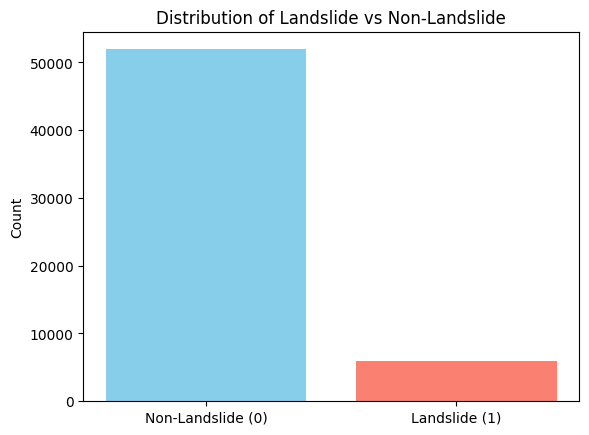

In [43]:
plot_landslide_distribution(df['landslide'].value_counts().sort_index())

/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


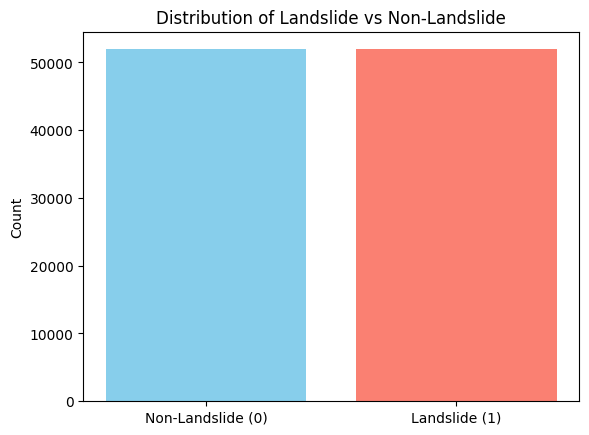

Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
       'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
       'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
       'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean', 'landslide', 'geometry', 'Soil_Type'],
      dtype='object')

In [44]:
X = df[sampling_columns]
y = df['landslide']
over = SMOTE(sampling_strategy='minority')
steps = [('o', over)]
pl = pipeline.Pipeline(steps=steps)
X_resampled, y_resampled = pl.fit_resample(X, y)
plot_landslide_distribution(y_resampled.value_counts().sort_index())
X_resampled['landslide'] = y_resampled
sampled_df = X_resampled
df.columns

In [45]:
def dataframe_to_dataset(df, shuffle=True, batch_size=32):
    labels = df.pop('landslide')
    ds = tf.data.Dataset.from_tensor_slices((dict(df), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds
    
train_df, test_df = train_test_split(sampled_df, test_size=0.3, random_state=42)
train_df_x = {col:tf.convert_to_tensor(train_df[col].values.reshape(-1, 1), dtype=tf.float32) for col in sampling_columns}
train_df_y = train_df['landslide'].values
test_df_x = {col:tf.convert_to_tensor(test_df[col].values.reshape(-1, 1)) for col in sampling_columns}
test_df_y = test_df['landslide'].values
train_ds = dataframe_to_dataset(train_df[columns])

In [46]:
learning_rate = 1e-05
decay_steps=10000
decay_rate = 0.9

binary_loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=learning_rate, decay_steps=decay_steps, decay_rate=decay_rate
)


data_train_loss = tf.keras.metrics.Mean(name="data train loss")
physics_train_loss = tf.keras.metrics.Mean(name="newmark train loss")
data_train_accuracy = tf.keras.metrics.BinaryAccuracy("data train accuracy")
newmark_train_mae = tf.keras.metrics.MeanAbsoluteError("Newmark MAE")


optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

#Pre Process first turn train_df into a list of list

train_val = []
for col in sampling_columns:
    train_val.append(train_df[col].values)

model = CotabatoModel(sampling_columns)
model.adapt_normalizers(train_val)
# model.build(train_df_x)

In [47]:
minimum_delta = 0.0003
patience = 5

In [48]:
def step(X_train, Y_train):
    
    with tf.GradientTape() as tape:
        predicted_values = model(X_train)
        data_loss = binary_loss_fn(Y_train, predicted_values)

    gradients = tape.gradient(data_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    del tape

    return data_loss

In [49]:
def transform_batch_train(x_train, start, end):
    return {col: x_train[col][start:end] for col in sampling_columns}

In [50]:
def train_model(x_train, y_train, batch_size, epochs=50):
    best_val_loss = 100
    local_patience = 0

    num_updates = y_train.shape[0] // batch_size
    maes = []
    epoch_total_loss = []
    epoch_data_loss = []
    epoch_physics_loss = []
    
    for epoch in range(epochs):
        if local_patience >= patience:
            print("Early Stopping now!")
            return epoch_total_loss, epoch_data_loss, epoch_physics_loss

        data_train_accuracy.reset_state()
        newmark_train_mae.reset_state()
        

        print(f"Starting epoch {epoch + 1}")
        epoch_start = time.time()

        data_losses = []
        total_losses = []
        physics_losses = []
        
        for i in range(0, num_updates):
            start = i * batch_size
            end = start + batch_size
            
            X_batch_train, Y_batch_train = transform_batch_train(x_train, start, end), y_train[start:end]
            data_loss = step(X_batch_train, Y_batch_train)

            data_losses.append(data_loss)
           
        print(f"data loss: {np.mean(data_losses)}")
        
        
        epoch_total_loss.append(np.mean(total_losses))
        epoch_data_loss.append(np.mean(data_losses))
        epoch_physics_loss.append(np.mean(physics_losses))


        epoch_end = time.time()
        epoch_train_time = epoch_end - epoch_start
        print(f"Took {epoch_train_time:.4f} seconds to run the epoch")

        # if total_loss_mean < best_val_loss - minimum_delta:
        #     best_val_loss = total_loss_mean
        #     local_patience = 0
        # else:
        #     local_patience += 1
              
    return epoch_total_loss, epoch_data_loss, epoch_physics_loss, maes

In [51]:
test_df = {col:tf.convert_to_tensor(df[col].values.reshape(-1, 1)) for col in sampling_columns}

In [52]:
total_loss, data_loss, physics_loss, maes = train_model(train_df_x, train_df_y, 256)


Starting epoch 1
data loss: 1.493686556816101
Took 11.0027 seconds to run the epoch
Starting epoch 2


/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


data loss: 1.4709157943725586
Took 10.7577 seconds to run the epoch
Starting epoch 3
data loss: 1.4438706636428833
Took 10.8398 seconds to run the epoch
Starting epoch 4
data loss: 1.4044305086135864
Took 10.7466 seconds to run the epoch
Starting epoch 5
data loss: 1.2812976837158203
Took 10.7369 seconds to run the epoch
Starting epoch 6
data loss: 0.7171754240989685
Took 10.7058 seconds to run the epoch
Starting epoch 7
data loss: 0.6234490871429443
Took 10.6885 seconds to run the epoch
Starting epoch 8
data loss: 0.6039896011352539
Took 10.6687 seconds to run the epoch
Starting epoch 9
data loss: 0.5865560173988342
Took 10.6775 seconds to run the epoch
Starting epoch 10
data loss: 0.5697820782661438
Took 10.6998 seconds to run the epoch
Starting epoch 11
data loss: 0.5533378720283508
Took 10.6782 seconds to run the epoch
Starting epoch 12
data loss: 0.5371786952018738
Took 10.6840 seconds to run the epoch
Starting epoch 13
data loss: 0.5219085216522217
Took 10.6604 seconds to run the

In [53]:
model.save('trainedWeights/data-driven/model2.keras')

In [54]:
model.summary()

Model: "cotabato_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_40                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_41                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_42                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_43                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_44                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_45                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_46                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_47                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_48                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_49                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_50                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_51                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_52                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_53                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_54                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_55                │ (72706)                │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_56                │ (72706)                │             

 Total params: 51,713 (202.08 KB)

 Trainable params: 51,525 (201.27 KB)

 Non-trainable params: 188 (832.00 B)

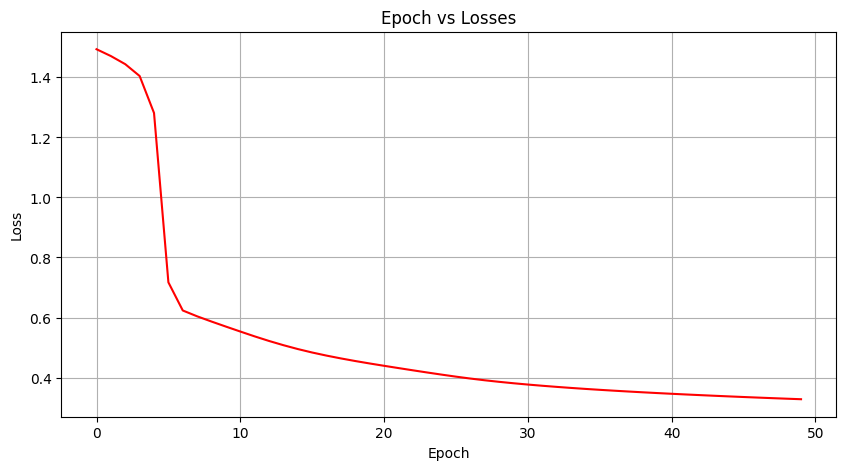

In [55]:
epochs = list(range(len(total_loss)))

plt.figure(figsize=(10, 5))

plt.plot(epochs, total_loss, color='green', label="Total Loss")
plt.plot(epochs, data_loss, color='red', label="Data Loss")
plt.plot(epochs, physics_loss, color='blue', label="Physics Loss")
plt.title("Epoch vs Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

(       DN    BD_mean   Clay_mean   Sand_mean   Silt_mean  NDVI_mean  Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  ...  landslide  landslide_probability  landslide_preds       confusion  sus_pinn_landslide  sus_pinn_ground truth        ds  cohesion  internal_friction                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

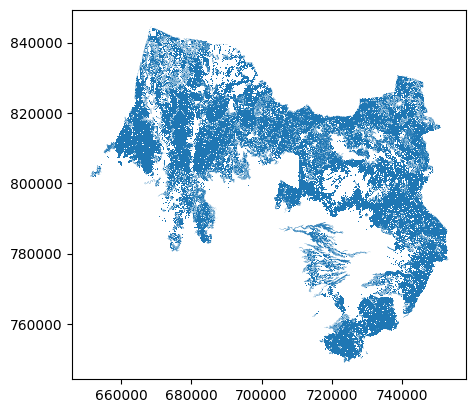

In [56]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation.gpkg')
df.head(), df.plot()

In [57]:
df['Soil_Type'] = df['Soil Type']
test_df = {col:tf.convert_to_tensor(df[col].values.reshape(-1, 1)) for col in sampling_columns}


7797/7797 ━━━━━━━━━━━━━━━━━━━━ 5s 608us/step
count    243540.000000
mean         11.166675
std           0.484111
min           9.754045
25%          10.930249
50%          11.196428
75%          11.522299
max          13.862825
Name: BUK_mean, dtype: float64
count    5958.000000
mean       11.489031
std         0.837879
min         9.857922
25%        10.944188
50%        11.238886
75%        11.873031
max        14.009266
Name: BUK_mean, dtype: float64


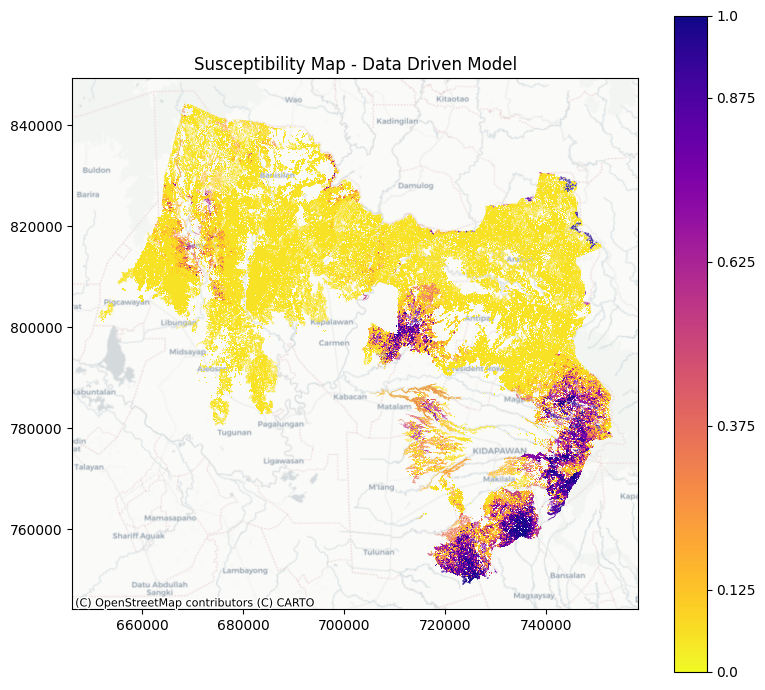

In [58]:
origin_preds = model.predict(test_df)
df['sus'] = origin_preds
# df['displacement'] = origin_preds['displacement']
# print(df[df['landslide'] == 0]['sus'].describe())
# print(df[df['landslide'] == 0]['displacement'].describe())
print(df[df['landslide'] == 0]['BUK_mean'].describe())
print(df[df['landslide'] == 1]['BUK_mean'].describe())
plot_susceptibility_map(df, origin_preds, 'Data Driven Model', "Susceptibility Map")
# plot_displacement_map(df, origin_preds['displacement'], 'displacement')

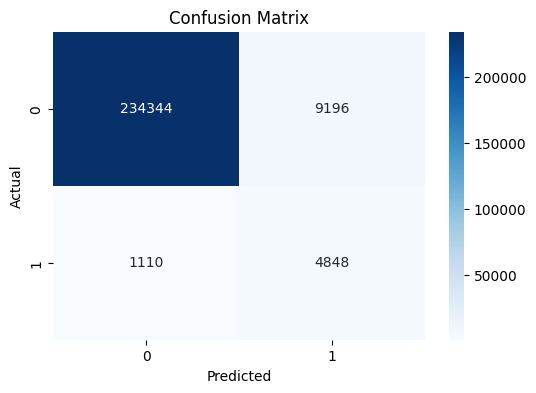

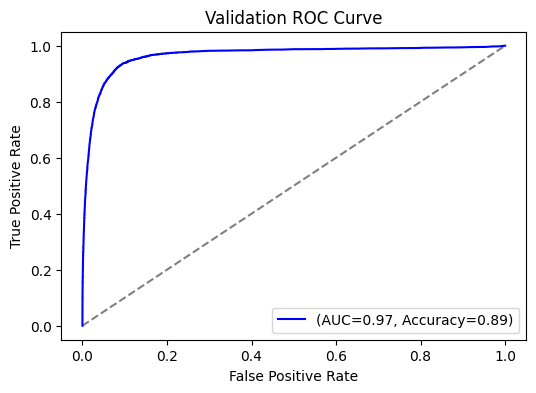

In [59]:

import importlib, metrics
importlib.reload(metrics)
from metrics import plot_confusion_matrix, plot_auc, plot_auc_with_distribution, plot_auc_with_boxplot
plot_confusion_matrix(origin_preds, df['landslide'])
plot_auc(df['landslide'], origin_preds)

In [60]:
import shap
from data import dataframe_to_input_list

train_df, test_df = train_test_split(sampled_df, test_size=0.3, random_state=42)


background_inputs = dataframe_to_input_list(train_df, sampling_columns)

#Creates a symbolic feature so that the model's feature importance can be assessed using shap
#Shap does only accept model built using functional API / Sequential API. 

inputs = [tf.keras.Input(shape=(1,), name=col) for col in sampling_columns]

inputs_dict = {col:tensor for col, tensor in zip(sampling_columns, inputs)}

# inputs = []
output = model(inputs_dict)

#Wraps the current model implementation as a functional model
functional_wrapped_model = tf.keras.Model(inputs=inputs, outputs=output)

explainer = shap.GradientExplainer(model=functional_wrapped_model, data=background_inputs)

test_inputs = dataframe_to_input_list(test_df, sampling_columns)

shap_values = explainer.shap_values(test_inputs)
X_test = test_df[sampling_columns].to_numpy()

2 (31160, 20)


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_3778/1881886388.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=sampling_columns)


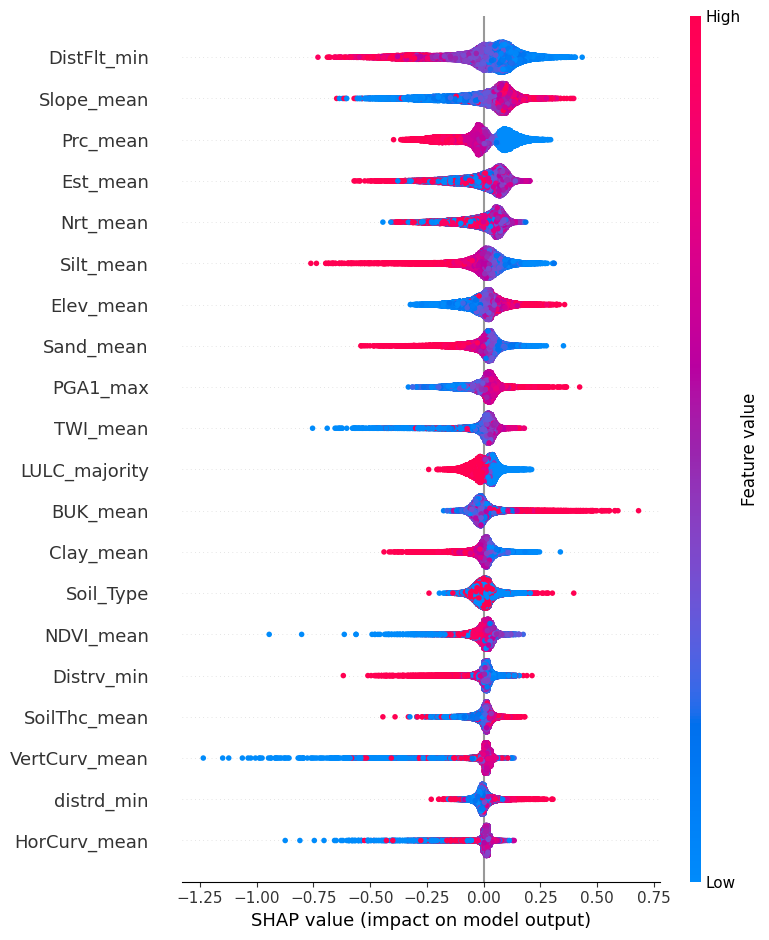

<Figure size 640x480 with 0 Axes>

In [61]:
# Plot summary plot
shap_values = np.array(shap_values)
shap_values = np.squeeze(shap_values)   # removes extra (1,1) dims
shap_values = shap_values.T
print(shap_values.ndim, shap_values.shape)

shap.summary_plot(shap_values, X_test, feature_names=sampling_columns)
plt.tight_layout()
plt.savefig(f'/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/figures/v2/historical/pinn-phase7-feature-importance.png', format="png")


/var/folders/dz/wrg2699d4jq7zd26swc8s2wm0000gn/T/ipykernel_3778/4173524506.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


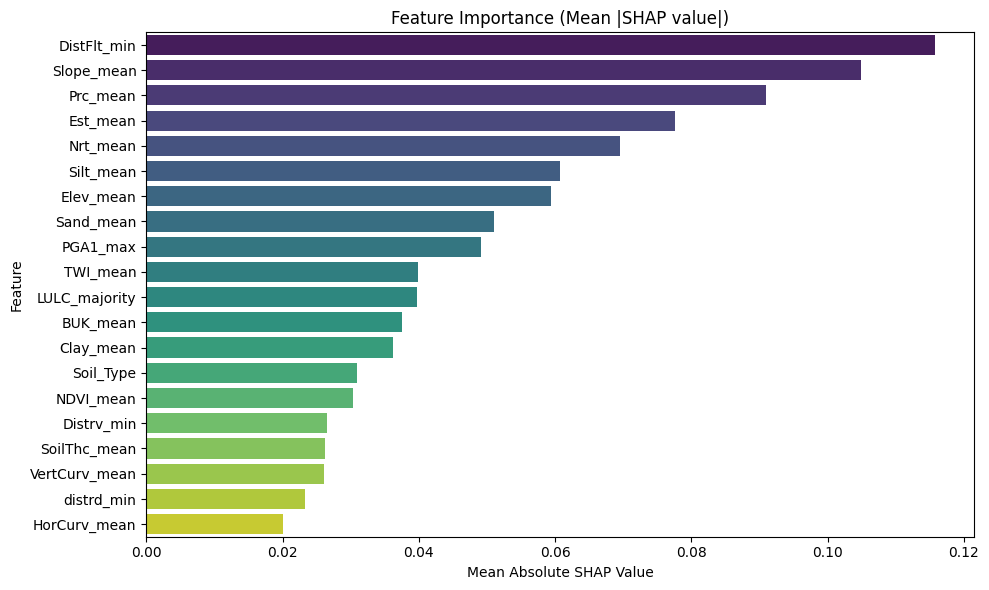

In [62]:
shap_vals = shap_values.T

shap_vals.shape

mean_abs_shap = np.mean(np.abs(shap_vals), axis=1)
mean_abs_shap

feature_importance = pd.DataFrame({
    "feature": sampling_columns,
    "importance": mean_abs_shap
})
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance,
    palette="viridis"
)
plt.title("Feature Importance (Mean |SHAP value|)")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [63]:
#Plot displacement produced by the model vs the Newmark calculation
plt.figure(figsize=(10, 5))

pga = test_df['PGA1_max']

newmark_input = {
    "coh":origin_preds["cohesion"],
    "ifi":origin_preds["friction_angle"],
    "pga":pga,
    "bulk_unit_weight":test_df['BUK_mean'],
    "slope":test_df['Slope_mean']
}

displacement, _ = calculate_newmark(**newmark_input)


plt.scatter(pga, displacement, color='green', label="Total Loss")
plt.scatter(pga, origin_preds['displacement'], color='red', label="Data Loss")

plt.title("Estimated Displacement vs Newmark Displacement")
plt.xlabel("PGA")
plt.ylabel("Newmark")
plt.grid(True)
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 1000x500 with 0 Axes>

In [ ]:
df.to_file("data/historical/v2/revised_pinn_validation.gpkg", layer="places", driver="GPKG")